# <span style="color:Orange;font-family:oswald">**PULSE PRESSURE AMPLIFICATION | Assignment 1**
### <span style="color:maroon">***Shreenandan Sahu | CL24M013***

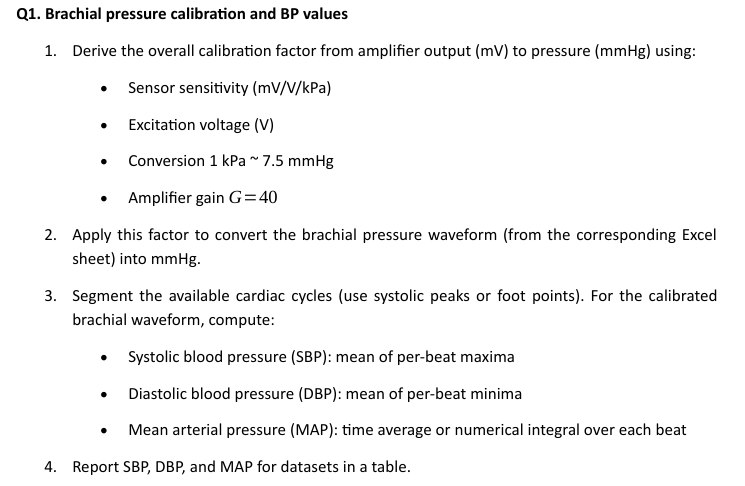

In [3]:
# Gain
G = 40
# Sensitivity
S = 0.5
# Excitation Voltage
Ev = 3.3
# 1Kpa to mmHg
P = 7.5
# Conversion Coefficient relating the output voltage to pressure in mmHg
Cc = G*S*Ev/P
print(Cc)

# Sampling Frequency to time conversion
Fsampling = 250
sampleIndex = 1
t = sampleIndex/Fsampling

# Vout=Cc*Pin
# Pin=(1/Cc)*Vout

8.8


### Importing necessary libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# pip install openpyxl

In [5]:
# Preparing the Excel Sheet and checking for the sheet names in the files
path = "Assignment_1_all_signals_combined.xlsx"
xls = pd.ExcelFile(path)
print(xls.sheet_names)
sheet_names_list = xls.sheet_names
pressure_sheet_index = [0, 2, 3, 5, 6, 8]
# for i in preussure_sheet_index:
#     print(sheet_names_list[i])

['A_brachial', 'A_carotid', 'A_femoral', 'C_brachial', 'C_carotid', 'C_femoral', 'B_brachial', 'B_carotid', 'B_femoral']


### <span style="color:orange;font-family:oswald">**MAIN ALGORITHM**

In [6]:
# Filtering Using Moving average filter and then detecting the minima in the signal to track the time points.


# Moving Average Filter
def moving_average(signal: np.ndarray, window_size: int) -> np.ndarray:
    cumsum = np.cumsum(signal)
    moving_avg = np.zeros(len(signal))

    for i in range(len(moving_avg)-window_size+1):
        if i == 0:
            moving_avg[i] = cumsum[i+window_size-1]/window_size
        else:
            moving_avg[i] = (cumsum[i+window_size-1]-cumsum[i-1])/window_size
    moving_avg[-window_size+1:] = signal[-window_size+1:]

    return moving_avg

# Minima Detection (windowed minima)


def min_pressure(pressure: np.ndarray, window=30) -> list:
    timepoints = []
    timepoints.append(np.argmin(pressure[:window]))
    for i in range(window, len(pressure)-window):
        local_window = pressure[i-window:i+window]
        if pressure[i] == np.min(local_window):
            timepoints.append(i)
    timepoints.append(np.argmin(pressure[:-window]))
    return timepoints

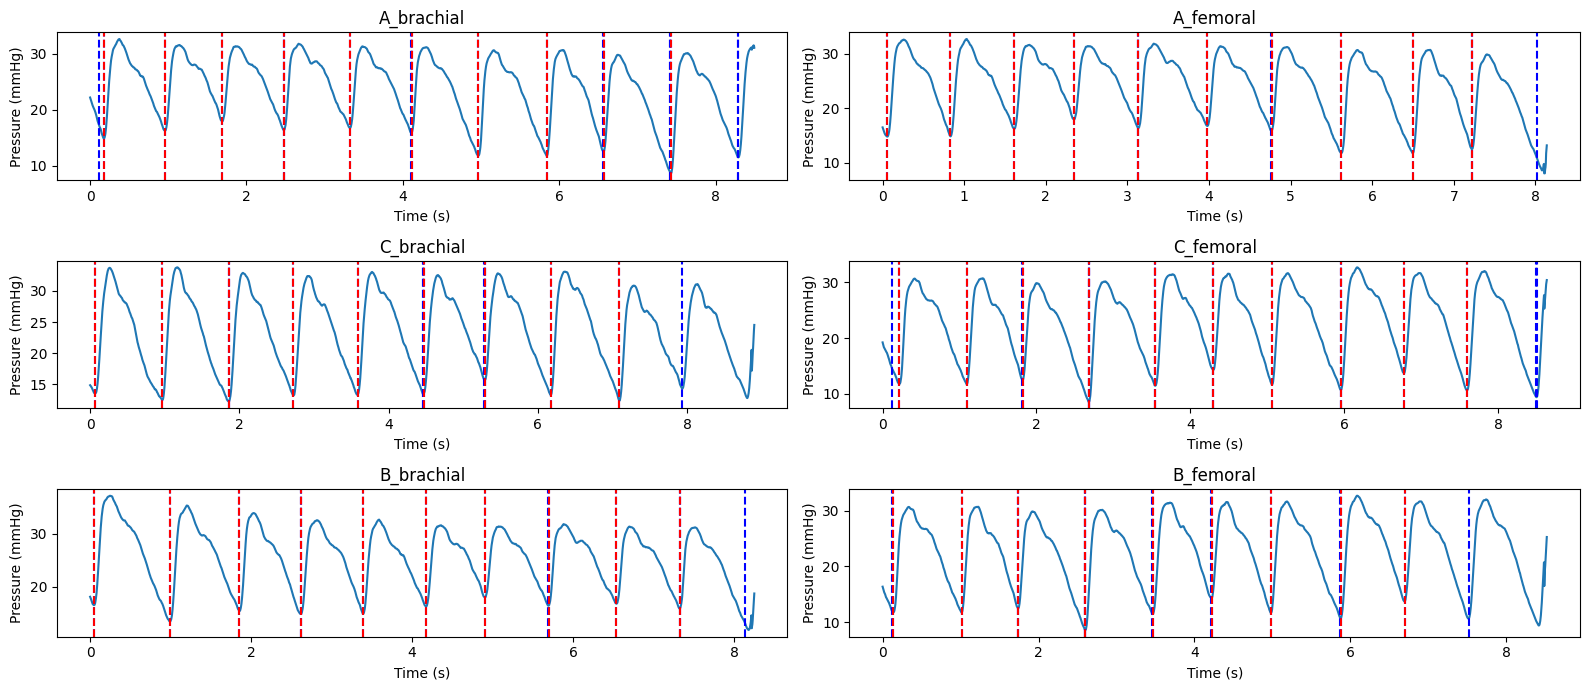

In [7]:
plt.figure(figsize=(16, 7))
for i in pressure_sheet_index:
    df = pd.read_excel(path, sheet_name=sheet_names_list[i])

    pressure = (df.iloc[:, 1])*(1000/Cc)
    pressure = moving_average(pressure, 10)
    time = (df.iloc[:, 0])*(0.004)
    max_pressure_points = min_pressure(pressure)
    plt.subplot(3, 2, (pressure_sheet_index.index(i)+1))
    plt.plot(time, pressure)
    for j in max_pressure_points:
        plt.axvline(x=time[j], color="b", linestyle="--")
    # marked by red dashed line
    for j in range(len(max_pressure_points)-1):
        if (time[max_pressure_points[j+1]]-time[max_pressure_points[j]])>0.3: # checking if the time difference between two beats is greater than 0.3s to avoid fake beats due to noise
            plt.axvline(x=time[max_pressure_points[j]], color="r", linestyle="--")
    plt.title(sheet_names_list[i])
    plt.xlabel("Time (s)")
    plt.ylabel("Pressure (mmHg)")
    # plt.grid()
plt.tight_layout()

plt.show()

#### <span style="color:#669bbc;font-family:oswald">**Function To calculate SBP DBP and MAP**</style>

In [8]:
# SBP DBP MAP Calculation

def sbp_dbp_map(pressure: np.ndarray) -> list:
    timepoints = min_pressure(pressure)
    SBP = []
    DBP = []
    MAP123 = []
    MAP = []

    for i in range(1, len(timepoints)-1):
        mini_window = pressure[timepoints[i-1]:timepoints[i]]
        SBP.append(np.max(mini_window))
        DBP.append(np.min(mini_window))
        MAP123.append((2*DBP[-1]+SBP[-1])/3)
        MAP.append(np.sum(mini_window)/len(mini_window))
    return SBP, DBP, MAP123, MAP

In [9]:
print("| SHEET NAME | SBP | DBP | MAP123 | MAP |\n|------|------|------|------|------|")
for i in pressure_sheet_index:
    df = pd.read_excel(path, sheet_name=sheet_names_list[i])
    pressure = (df.iloc[:, 1])*(1000/Cc)
    pressure = moving_average(pressure, 10)
    sbp, dbp, map123, map = sbp_dbp_map(pressure)
    print(
        f"| {sheet_names_list[i]} | {np.mean(sbp):.2f} mmHg | {np.mean(dbp):.2f} mmHg | {np.mean(map123):.2f} mmHg | {np.mean(map):.2f} mmHg |")

| SHEET NAME | SBP | DBP | MAP123 | MAP |
|------|------|------|------|------|
| A_brachial | 24.58 mmHg | 13.25 mmHg | 17.02 mmHg | 20.10 mmHg |
| A_femoral | 27.38 mmHg | 14.54 mmHg | 18.82 mmHg | 22.26 mmHg |
| C_brachial | 27.18 mmHg | 13.35 mmHg | 17.96 mmHg | 21.02 mmHg |
| C_femoral | 23.18 mmHg | 10.85 mmHg | 14.96 mmHg | 18.31 mmHg |
| B_brachial | 28.74 mmHg | 15.26 mmHg | 19.75 mmHg | 23.26 mmHg |
| B_femoral | 23.33 mmHg | 11.04 mmHg | 15.14 mmHg | 18.54 mmHg |


### <span style="color:Yellow;font-family:oswald"> **Results and Interpretation** </span>
| SHEET NAME | SBP | DBP | MAP123 | MAP |
|------|------|------|------|------|
| A_brachial | 24.58 mmHg | 13.25 mmHg | 17.02 mmHg | 20.10 mmHg |
| A_femoral | 27.38 mmHg | 14.54 mmHg | 18.82 mmHg | 22.26 mmHg |
| C_brachial | 27.18 mmHg | 13.35 mmHg | 17.96 mmHg | 21.02 mmHg |
| C_femoral | 23.18 mmHg | 10.85 mmHg | 14.96 mmHg | 18.31 mmHg |
| B_brachial | 28.74 mmHg | 15.26 mmHg | 19.75 mmHg | 23.26 mmHg |
| B_femoral | 23.33 mmHg | 11.04 mmHg | 15.14 mmHg | 18.54 mmHg |

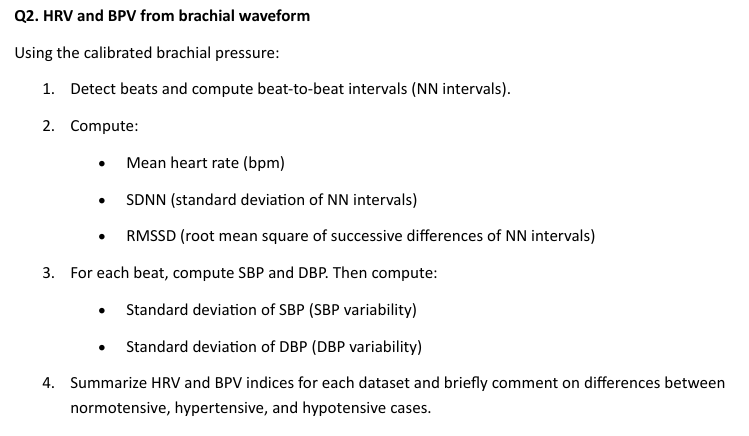

In [10]:
path = "Assignment_1_all_signals_combined.xlsx"
xls = pd.ExcelFile(path)
print(xls.sheet_names)
sheet_names_list = xls.sheet_names
pressure_sheet_index = [0, 6, 3,]

['A_brachial', 'A_carotid', 'A_femoral', 'C_brachial', 'C_carotid', 'C_femoral', 'B_brachial', 'B_carotid', 'B_femoral']


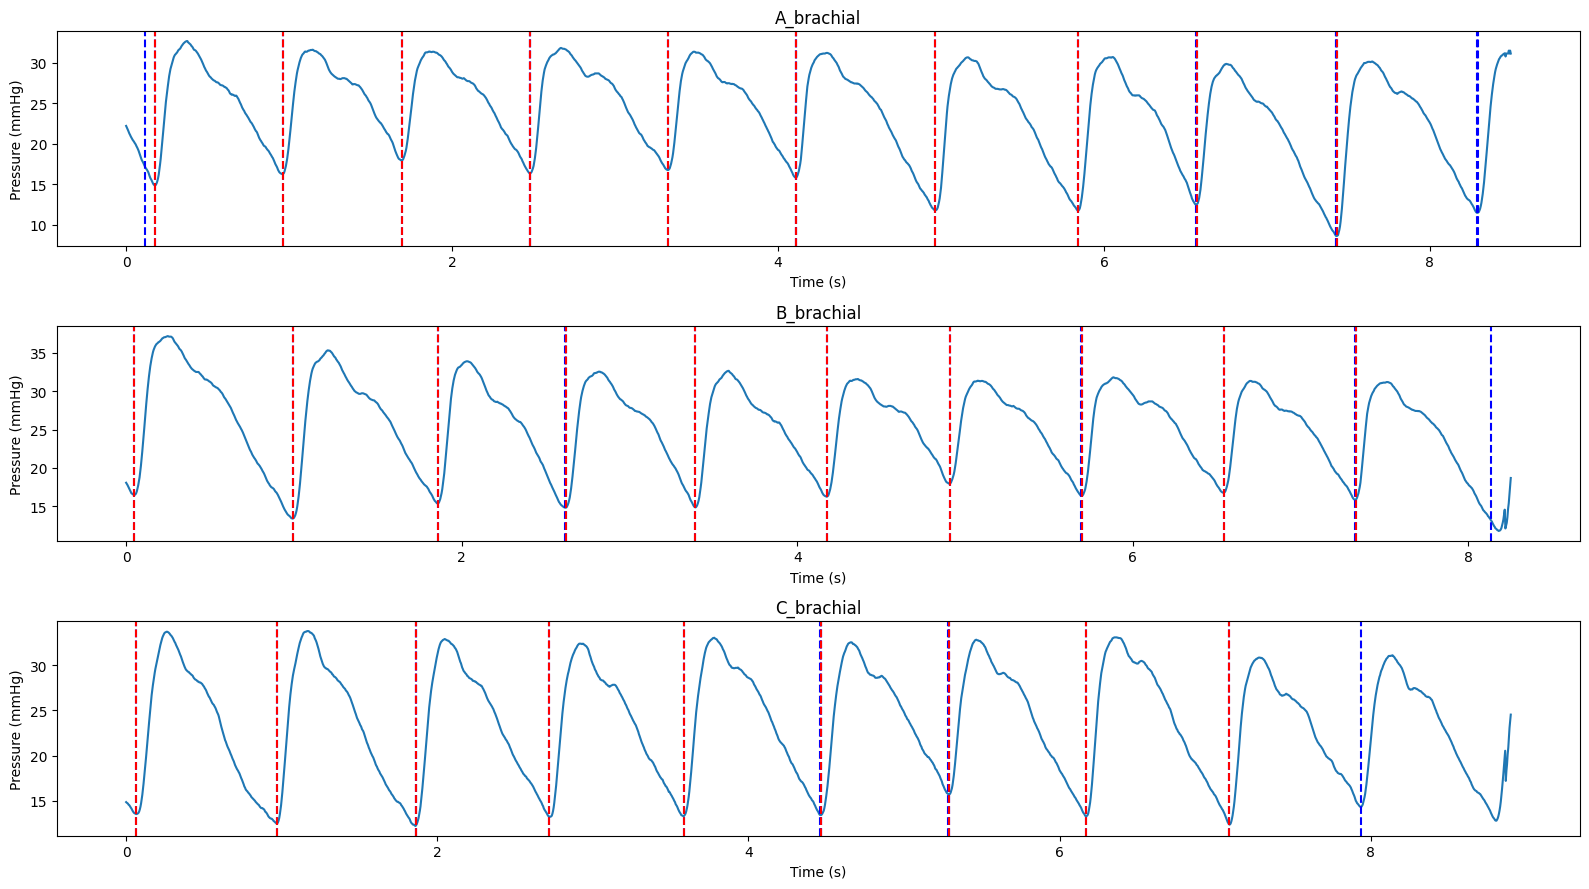

In [11]:
plt.figure(figsize=(16,9 ))
for i in pressure_sheet_index:
    df = pd.read_excel(path, sheet_name=sheet_names_list[i])

    pressure = (df.iloc[:, 1])*(1000/Cc)
    pressure = moving_average(pressure, 10)
    time = (df.iloc[:, 0])*(0.004)
    max_pressure_points = min_pressure(pressure)
    plt.subplot(3, 1, (pressure_sheet_index.index(i)+1))
    plt.plot(time, pressure)
    #marked by blue dashed line
    for j in max_pressure_points:
        plt.axvline(x=time[j], color="b", linestyle="--")
    # marked by red dashed line
    for j in range(len(max_pressure_points)-1):
        if (time[max_pressure_points[j+1]]-time[max_pressure_points[j]])>0.3: # checking if the time difference between two beats is greater than 0.3s to avoid fake beats due to noise
            plt.axvline(x=time[max_pressure_points[j]], color="r", linestyle="--")
    plt.title(sheet_names_list[i])
    plt.xlabel("Time (s)")
    plt.ylabel("Pressure (mmHg)")
    # plt.grid()
plt.tight_layout()

plt.show()

In [12]:
print("| SHEET NAME | AVERAGE BEAT INTERVAL (s) | HEART RATE (bpm) | SDNN (ms) | RMSSD (ms) |\n|------|------|------|------|------|")

for i in pressure_sheet_index:
    df = pd.read_excel(path, sheet_name=sheet_names_list[i])
    beat_intervals = []
    avg_beat_intterval = 0
    pressure = (df.iloc[:, 1])*(1000/Cc)
    pressure = moving_average(pressure, 10)
    time = (df.iloc[:, 0])*(0.004)
    min_pressure_points = min_pressure(pressure)
    for j in range(len(min_pressure_points)-1):
        # to avoid fake beat coming due to noise we will limit the minimum time between two beats to be 0.3s (which corresponds to a heart rate of 200 bpm)
        if (time[min_pressure_points[j+1]]-time[min_pressure_points[j]]) > 0.3:
            beat_intervals.append(
                time[min_pressure_points[j+1]]-time[min_pressure_points[j]])
    # print(beat_intervals)
    print(f"| {sheet_names_list[i]} | {np.mean(beat_intervals):.2f} | {60/np.mean(beat_intervals):.2f} | {np.std(beat_intervals)*1000:.2f} | {np.sqrt(np.mean(np.diff(beat_intervals)**2))*1000:.2f} |")

| SHEET NAME | AVERAGE BEAT INTERVAL (s) | HEART RATE (bpm) | SDNN (ms) | RMSSD (ms) |
|------|------|------|------|------|
| A_brachial | 0.81 | 74.11 | 52.34 | 80.52 |
| B_brachial | 0.81 | 74.29 | 59.29 | 58.85 |
| C_brachial | 0.87 | 68.74 | 29.68 | 45.28 |


| SHEET NAME | AVERAGE BEAT INTERVAL (s) | HEART RATE (bpm) | SDNN (ms) | RMSSD (ms) |
|------|------|------|------|------|
| A_brachial | 0.81 | 74.11 | 52.34 | 80.52 |
| B_brachial | 0.81 | 74.29 | 59.29 | 58.85 |
| C_brachial | 0.87 | 68.74 | 29.68 | 45.28 |

In [13]:
print("| SHEET NAME | SD_SBP | SD_DBP |\n|------|------|------|")
for i in pressure_sheet_index:
    df = pd.read_excel(path, sheet_name=sheet_names_list[i])
    SBP = []
    DBP = []
    avg_beat_intterval = 0
    pressure = (df.iloc[:, 1])*(1000/Cc)
    pressure = moving_average(pressure, 10)
    time = (df.iloc[:, 0])*(0.004)
    min_pressure_points = min_pressure(pressure)
    for j in range(len(min_pressure_points)-1):
        # to avoid fake beat coming due to noise we will limit the minimum time between two beats to be 0.3s (which corresponds to a heart rate of 200 bpm)
        if (time[min_pressure_points[j+1]]-time[min_pressure_points[j]]) > 0.3:
            # creating a small windo for a particular beat
            small_window = pressure[min_pressure_points[j]:min_pressure_points[j+1]]
            SBP.append(np.max(small_window))
            DBP.append(np.min(small_window))
    print(
        f"| {sheet_names_list[i]} | {np.std(SBP):.2f} mmHg | {np.std(DBP):.2f} mmHg |")

| SHEET NAME | SD_SBP | SD_DBP |
|------|------|------|
| A_brachial | 0.79 mmHg | 2.94 mmHg |
| B_brachial | 1.90 mmHg | 1.18 mmHg |
| C_brachial | 0.81 mmHg | 0.48 mmHg |


| SHEET NAME | SD_SBP | SD_DBP |
|------|------|------|
| A_brachial | 0.79 mmHg | 2.94 mmHg |
| B_brachial | 1.90 mmHg | 1.18 mmHg |
| C_brachial | 0.81 mmHg | 0.48 mmHg |

### <span style="color:Yellow;font-family:oswald"> **Results and Interpretation** </span>

| Dataset    | Avg Beat Interval (s) | Heart Rate (bpm) | SDNN (ms) | RMSSD (ms) | SD_SBP (mmHg) | SD_DBP (mmHg) | Observed Pattern                                                     |
| ---------- | --------------------- | ---------------- | --------- | ---------- | ------------- | ------------- | -------------------------------------------------------------------- |
| A_brachial | 0.81                  | 74.11            | 52.34     | 80.52      | 0.79          | 2.94          | Higher HRV, moderate BP variability – resembles normotensive pattern |
| B_brachial | 0.81                  | 74.29            | 59.29     | 58.85      | 1.90          | 1.18          | Highest SBP variability – resembles hypertensive-like pattern        |
| C_brachial | 0.87                  | 68.74            | 29.68     | 45.28      | 0.81          | 0.48          | Lowest HRV and BP variability – resembles hypotensive-like pattern   |


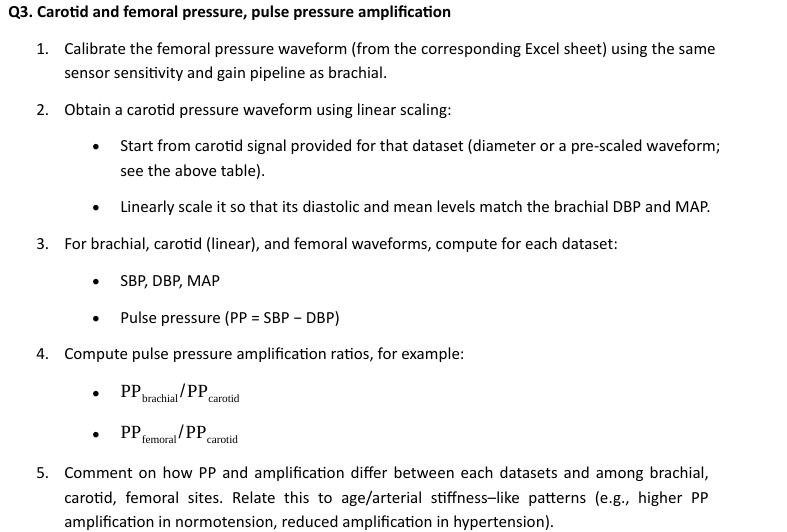

In [14]:
path = "Assignment_1_all_signals_combined.xlsx"
xls = pd.ExcelFile(path)
print(xls.sheet_names)
sheet_names_list = xls.sheet_names
pressure_sheet_index = [2,8,5]

['A_brachial', 'A_carotid', 'A_femoral', 'C_brachial', 'C_carotid', 'C_femoral', 'B_brachial', 'B_carotid', 'B_femoral']


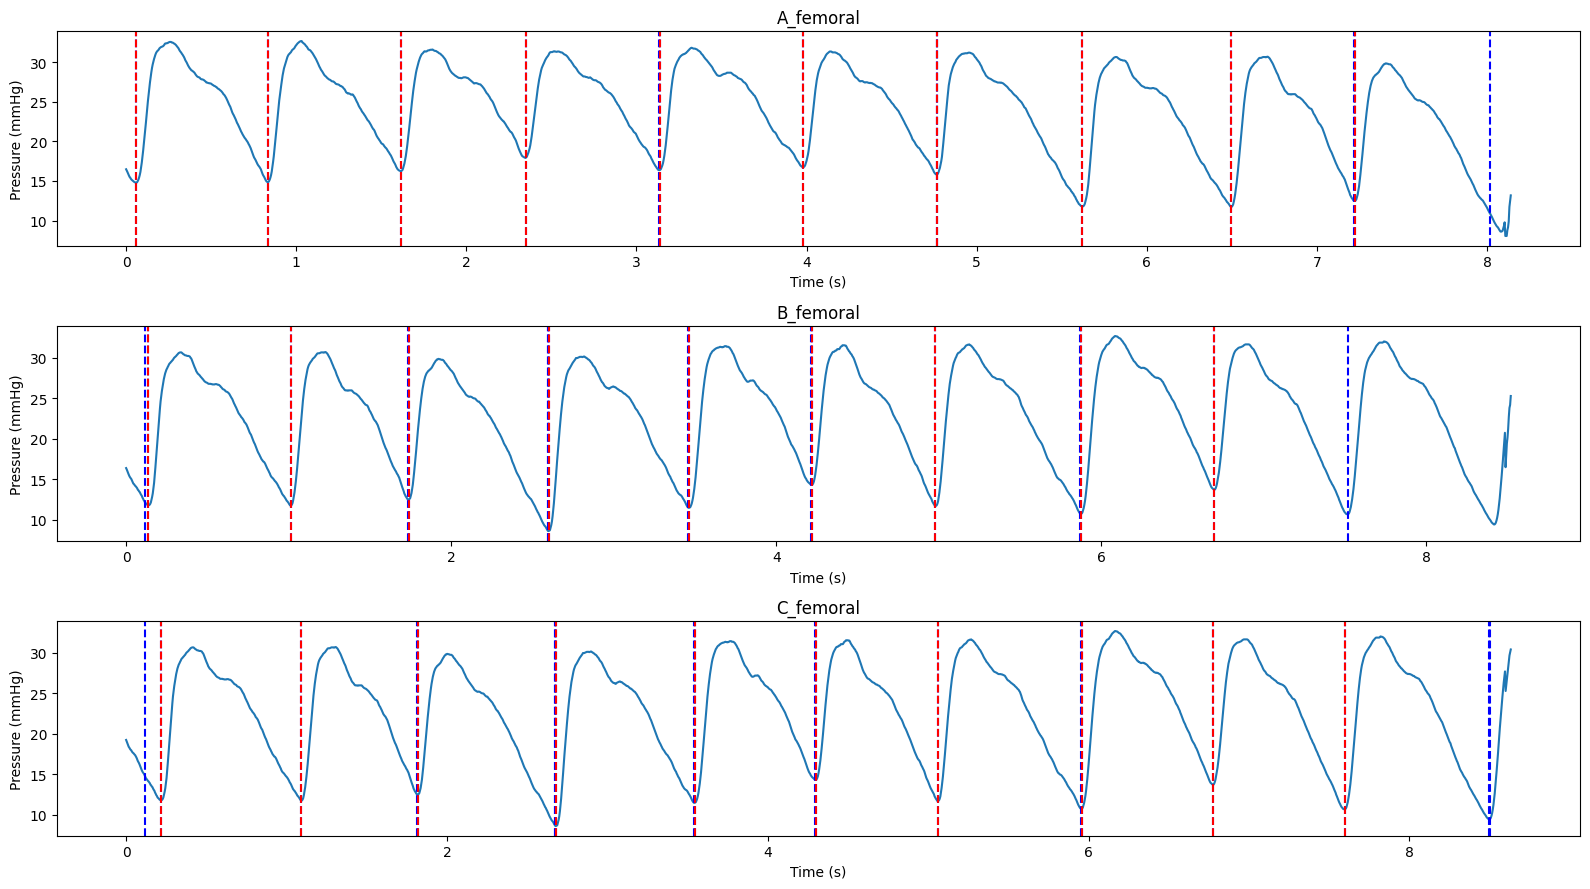

In [15]:
plt.figure(figsize=(16,9 ))
for i in pressure_sheet_index:
    df = pd.read_excel(path, sheet_name=sheet_names_list[i])

    pressure = (df.iloc[:, 1])*(1000/Cc)
    pressure = moving_average(pressure, 10)
    time = (df.iloc[:, 0])*(0.004)
    max_pressure_points = min_pressure(pressure)
    plt.subplot(3, 1, (pressure_sheet_index.index(i)+1))
    plt.plot(time, pressure)
    #marked by blue dashed line
    for j in max_pressure_points:
        plt.axvline(x=time[j], color="b", linestyle="--")
    # marked by red dashed line
    for j in range(len(max_pressure_points)-1):
        if (time[max_pressure_points[j+1]]-time[max_pressure_points[j]])>0.3: # checking if the time difference between two beats is greater than 0.3s to avoid fake beats due to noise
            plt.axvline(x=time[max_pressure_points[j]], color="r", linestyle="--")
    plt.title(sheet_names_list[i])
    plt.xlabel("Time (s)")
    plt.ylabel("Pressure (mmHg)")
    # plt.grid()
plt.tight_layout()

plt.show()

#### Derivation of P(carotid)
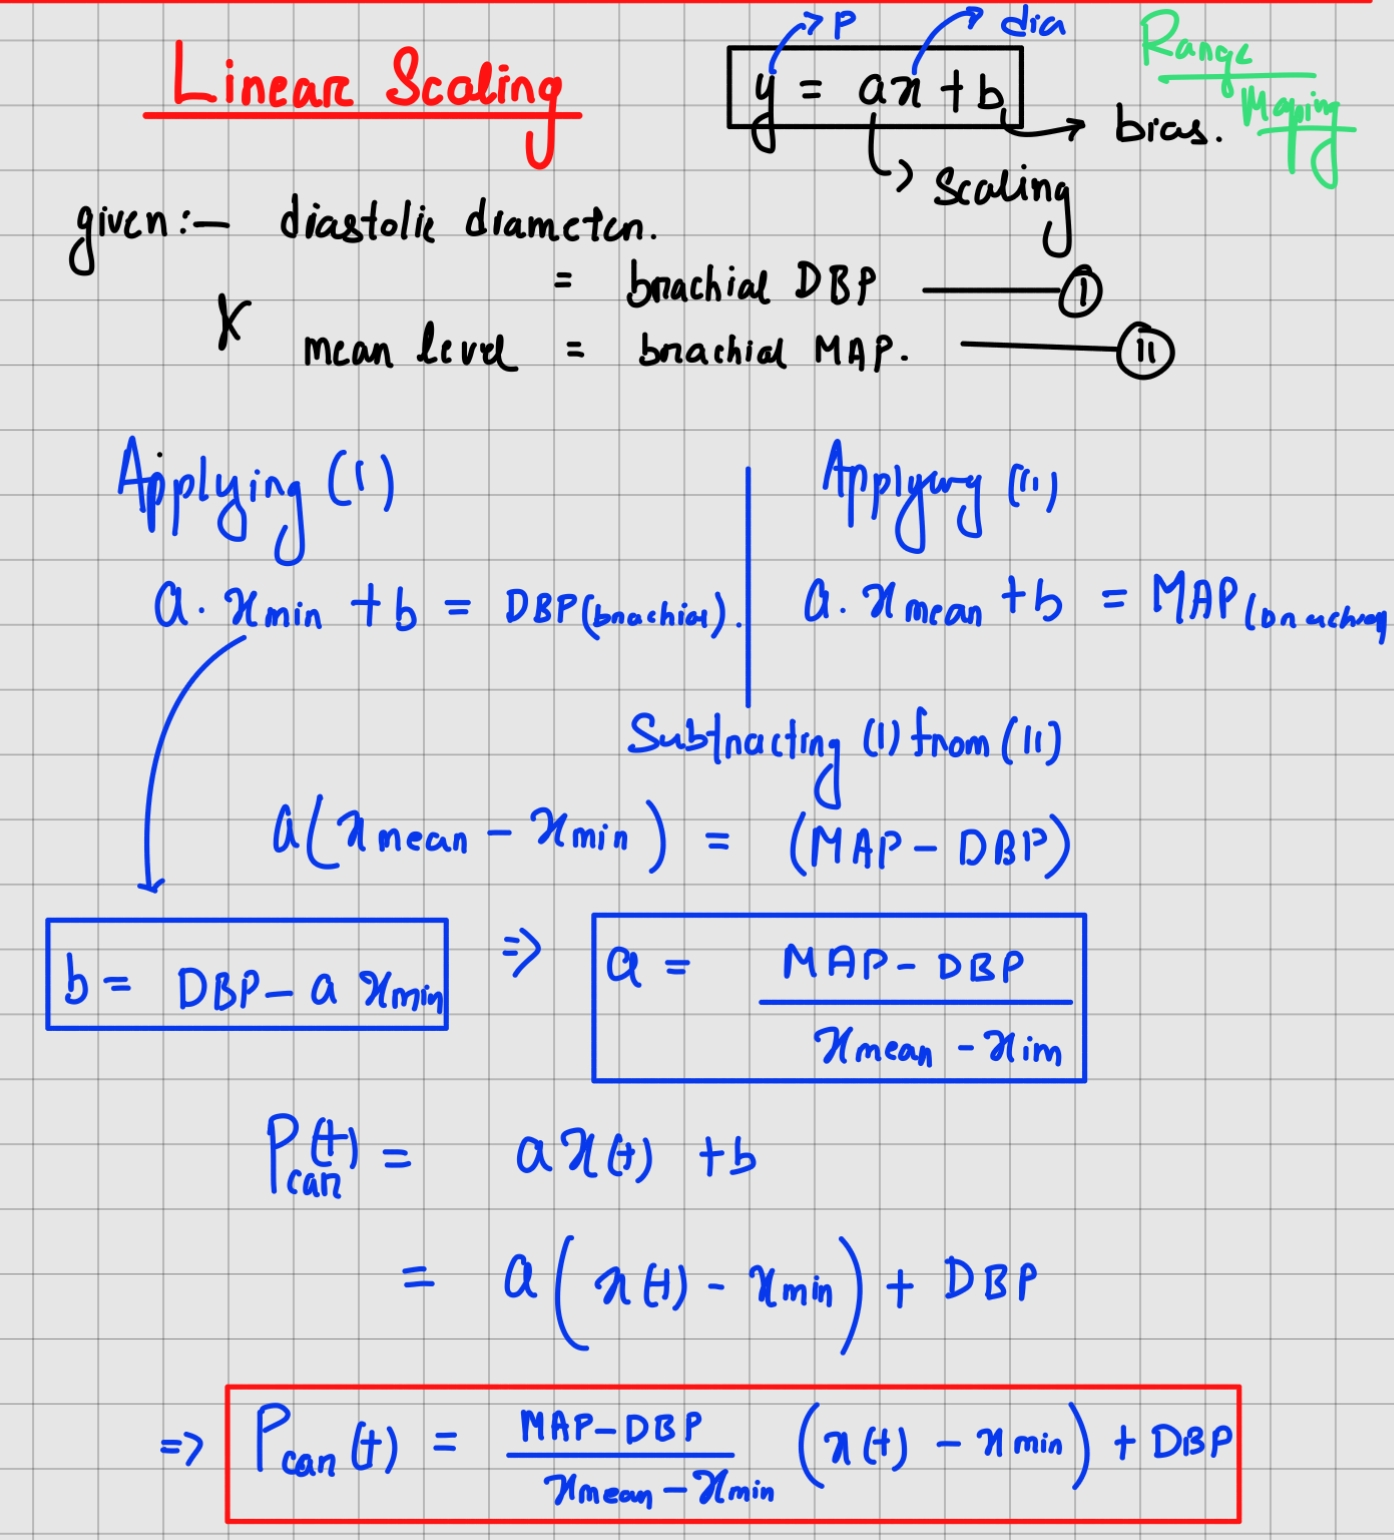


In [16]:
path = "Assignment_1_all_signals_combined.xlsx"
xls = pd.ExcelFile(path)
print(xls.sheet_names)
sheet_names_list = xls.sheet_names
diameter_sheet_index = [1,7,4]

['A_brachial', 'A_carotid', 'A_femoral', 'C_brachial', 'C_carotid', 'C_femoral', 'B_brachial', 'B_carotid', 'B_femoral']


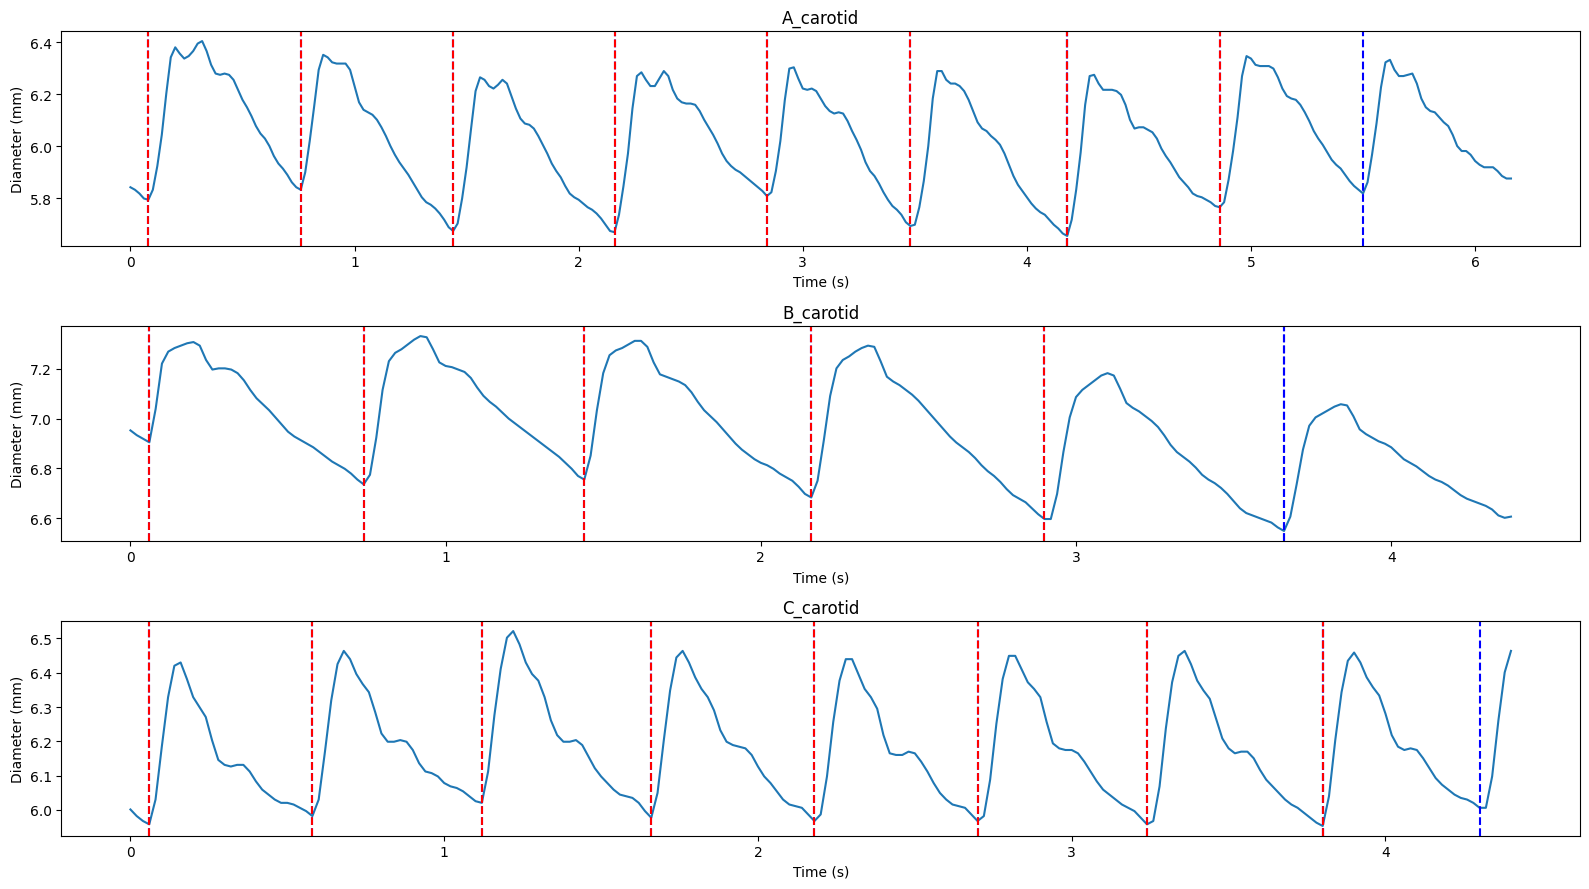

In [17]:
plt.figure(figsize=(16,9 ))
for i in diameter_sheet_index:
    df = pd.read_excel(path, sheet_name=sheet_names_list[i])

    diameter = (df.iloc[:, 1])
    diameter=moving_average(diameter,2)
    time = (df.iloc[:, 0])*(1/50) # since the diameter signal is sampled at 50 Hz
    min_diameter_points = min_pressure(diameter,5)
    plt.subplot(3, 1, (diameter_sheet_index.index(i)+1))
    plt.plot(time, diameter)
    #marked by blue dashed line
    for j in min_diameter_points:
        plt.axvline(x=time[j], color="b", linestyle="--")
    # marked by red dashed line
    for j in range(len(min_diameter_points)-1):
        if (time[min_diameter_points[j+1]]-time[min_diameter_points[j]])>0.3: # checking if the time difference between two beats is greater than 0.3s to avoid fake beats due to noise
            plt.axvline(x=time[min_diameter_points[j]], color="r", linestyle="--")
    plt.title(sheet_names_list[i])
    plt.xlabel("Time (s)")
    plt.ylabel("Diameter (mm)")
    # plt.grid()
plt.tight_layout()

plt.show()

In [18]:
print("| SHEET NAME | MIN DIAMETER (mm) | MEAN DIAMETER (mm) |\n|------|------|------|")
for i in diameter_sheet_index:
    diamin=[]
    diamean=[]
    df = pd.read_excel(path, sheet_name=sheet_names_list[i])
    diameter = (df.iloc[:, 1])
    diameter=moving_average(diameter,2)
    time = (df.iloc[:, 0])*(1/50) # since the diameter signal is sampled at 50 Hz
    min_diameter_points = min_pressure(diameter,5)
    for j in range(len(min_diameter_points)-1):
        if (time[min_diameter_points[j+1]]-time[min_diameter_points[j]])>0.3: # checking if the time difference between two beats is greater than 0.3s to avoid fake beats due to noise
            small_window=diameter[min_diameter_points[j]:min_diameter_points[j+1]]
            diamin.append(np.min(small_window))
            diamean.append(np.mean(small_window))
    print(f"| {sheet_names_list[i]} | {np.mean(diamin):.2f} mm | {np.mean(diamean):.2f} mm |")  


| SHEET NAME | MIN DIAMETER (mm) | MEAN DIAMETER (mm) |
|------|------|------|
| A_carotid | 5.70 mm | 6.03 mm |
| B_carotid | 6.67 mm | 6.99 mm |
| C_carotid | 5.97 mm | 6.18 mm |


| SHEET NAME | MIN DIAMETER (mm) | MEAN DIAMETER (mm) |
|------|------|------|
| A_carotid | 5.70 mm | 6.03 mm |
| B_carotid | 6.67 mm | 6.99 mm |
| C_carotid | 5.97 mm | 6.18 mm |

In [25]:
Xmean=[6.03,6.99,6.18]
Xmin=[5.70,6.67,5.97]
Bmap=[17.02,19.75,17.96]
Bdbp=[13.25,15.26,13.35]

In [26]:
path = "Assignment_1_all_signals_combined.xlsx"
xls = pd.ExcelFile(path)
print(xls.sheet_names)
sheet_names_list = xls.sheet_names
diameter_sheet_index = [1,7,4]

['A_brachial', 'A_carotid', 'A_femoral', 'C_brachial', 'C_carotid', 'C_femoral', 'B_brachial', 'B_carotid', 'B_femoral']


#### <span style="color:Yellow;font-family:oswald">**Linear Scaled Carotid Pressure from diameter**</style>

| SHEET NAME | SBP | DBP | MAP123 | MAP |
|------|------|------|------|------|
| A_carotid | 20.27 mmHg | 13.09 mmHg | 15.48 mmHg | 16.95 mmHg |
| B_carotid | 22.72 mmHg | 15.30 mmHg | 17.77 mmHg | 19.12 mmHg |
| C_carotid | 24.82 mmHg | 13.09 mmHg | 17.00 mmHg | 17.90 mmHg |


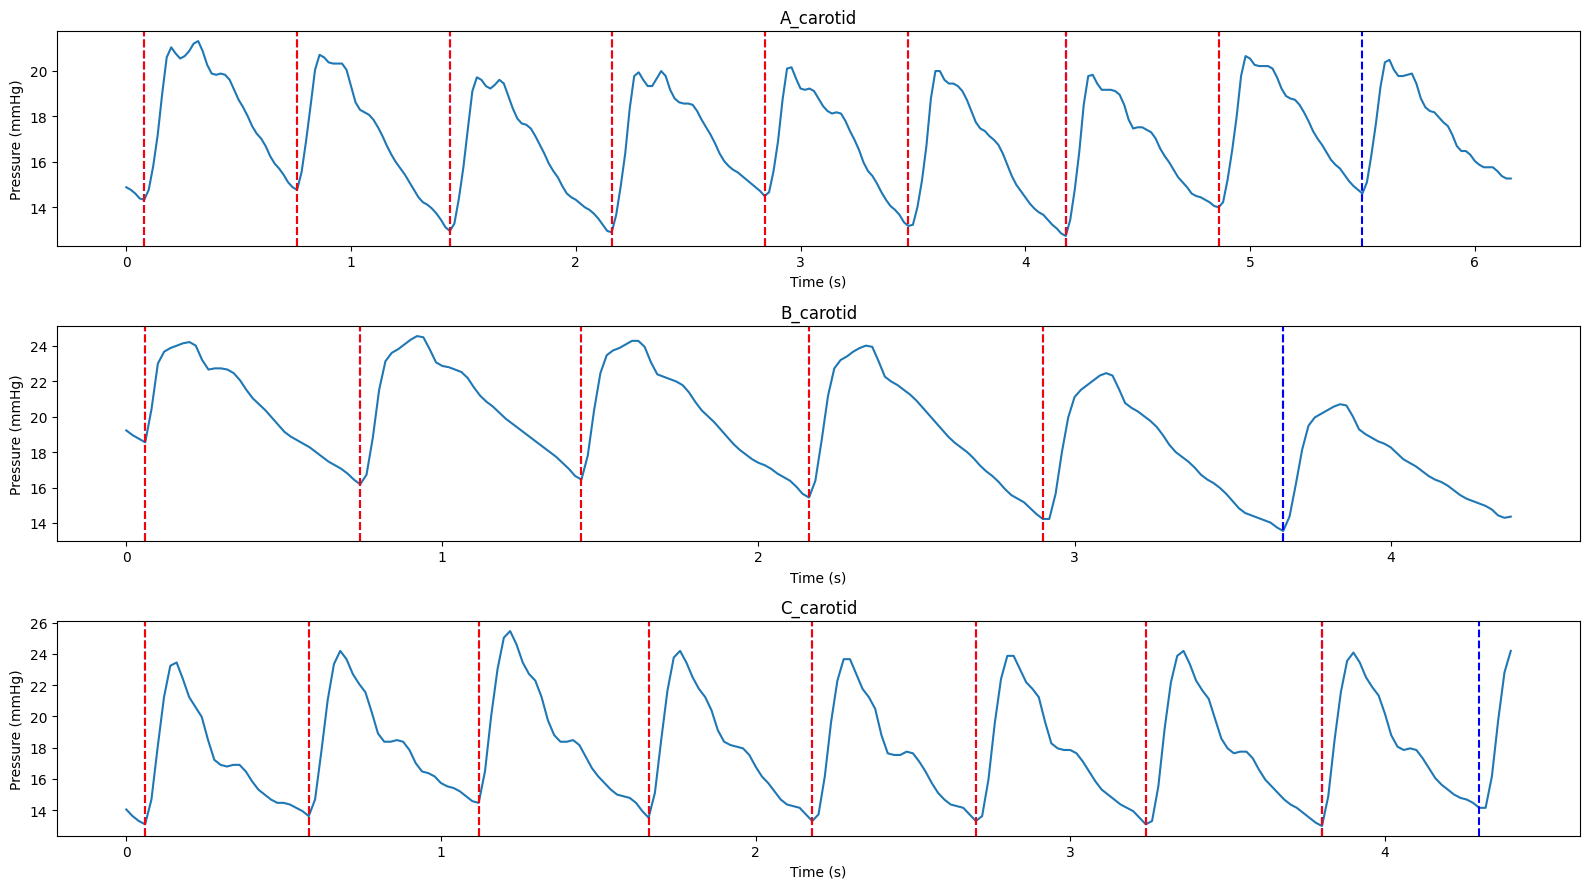

In [33]:
print("| SHEET NAME | SBP | DBP | MAP123 | MAP |\n|------|------|------|------|------|")
plt.figure(figsize=(16,9 ))
for i in diameter_sheet_index:
    df = pd.read_excel(path, sheet_name=sheet_names_list[i])

    diameter = (df.iloc[:, 1])
    diameter=moving_average(diameter,2)
    j=diameter_sheet_index.index(i)
    pressure= ((Bmap[j]-Bdbp[j])/(Xmean[j]-Xmin[j]))*(diameter-Xmin[j])+Bdbp[j]
    time = (df.iloc[:, 0])*(1/50) # since the diameter signal is sampled at 50 Hz
    min_pressure_points = min_pressure(pressure,5)
    sbp, dbp, map123, map = sbp_dbp_map(pressure)
    print(
        f"| {sheet_names_list[i]} | {np.mean(sbp):.2f} mmHg | {np.mean(dbp):.2f} mmHg | {np.mean(map123):.2f} mmHg | {np.mean(map):.2f} mmHg |")
    plt.subplot(3, 1, (diameter_sheet_index.index(i)+1))
    plt.plot(time, pressure)
    #marked by blue dashed line
    for j in min_pressure_points:
        plt.axvline(x=time[j], color="b", linestyle="--")
    # marked by red dashed line
    for j in range(len(min_pressure_points)-1):
        if (time[min_pressure_points[j+1]]-time[min_pressure_points[j]])>0.3: # checking if the time difference between two beats is greater than 0.3s to avoid fake beats due to noise
            plt.axvline(x=time[min_pressure_points[j]], color="r", linestyle="--")
    plt.title(sheet_names_list[i])
    plt.xlabel("Time (s)")
    plt.ylabel("Pressure (mmHg)")
    # plt.grid()
plt.tight_layout()

plt.show()


In [44]:
sheet_names = {0:"A",1:"B",2:"C"}
part_names={0:"Brachial",1:"Femoral",2:"Carotid"}

SBP =[ 
[24.58, 27.38, 20.27],
[28.74, 23.33, 22.72],
[27.18, 23.18, 24.82]
]

DBP = [
[13.25, 14.54, 13.09],
[15.26, 11.04, 15.30],
[13.35, 10.85, 13.09]]

pp=[]

for i in range(3):
    for j in range(3):
        pp_value = SBP[i][j] - DBP[i][j]
        pp.append(pp_value)
        print(f"PP of {sheet_names[i]} {part_names[j]}: {pp_value:.2f} mmHg")

for i in range(3):
    print(f"PPA Brachial/Carotid : {pp[3*i]/pp[3*i+2]:.2f} Femoral/Carotid : {pp[3*i+1]/pp[3*i+2]:.2f} for {sheet_names[i]}")
    
    

PP of A Brachial: 11.33 mmHg
PP of A Femoral: 12.84 mmHg
PP of A Carotid: 7.18 mmHg
PP of B Brachial: 13.48 mmHg
PP of B Femoral: 12.29 mmHg
PP of B Carotid: 7.42 mmHg
PP of C Brachial: 13.83 mmHg
PP of C Femoral: 12.33 mmHg
PP of C Carotid: 11.73 mmHg
PPA Brachial/Carotid : 1.58 Femoral/Carotid : 1.79 for A
PPA Brachial/Carotid : 1.82 Femoral/Carotid : 1.66 for B
PPA Brachial/Carotid : 1.18 Femoral/Carotid : 1.05 for C


## <span style="color:#d64045;font-family:oswald; font-weight:bolder;"> RESULT ANALYSIS </span>

<span style="color:#6a994e;font-family:oswald">

|  SHEET NAME  | SBP | DBP | MAP123 | MAP | PP |
|------|------|------|------|------|------|
| A_brachial | 24.58 mmHg | 13.25 mmHg | 17.02 mmHg | 20.10 mmHg | 11.33 mmHg |
| A_femoral | 27.38 mmHg | 14.54 mmHg | 18.82 mmHg | 22.26 mmHg | 12.84 mmHg |
| A_carotid | 20.27 mmHg | 13.09 mmHg | 15.48 mmHg | 16.95 mmHg | 7.18 mmHg |

</span>

<br>

<span style="color:#3a86ff;font-family:oswald">

|  SHEET NAME  | SBP | DBP | MAP123 | MAP | PP |
|------|------|------|------|------|------|
| B_brachial | 28.74 mmHg | 15.26 mmHg | 19.75 mmHg | 23.26 mmHg | 13.48 mmHg |
| B_femoral | 23.33 mmHg | 11.04 mmHg | 15.14 mmHg | 18.54 mmHg | 12.29 mmHg |
| B_carotid | 22.72 mmHg | 15.30 mmHg | 17.77 mmHg | 19.12 mmHg | 7.42 mmHg |

</span>

<br>

<span style="color:#f48c06;font-family:oswald">

|  SHEET NAME  | SBP | DBP | MAP123 | MAP | PP |
|------|------|------|------|------|------|
| C_brachial | 27.18 mmHg | 13.35 mmHg | 17.96 mmHg | 21.02 mmHg | 13.83 mmHg |
| C_femoral | 23.18 mmHg | 10.85 mmHg | 14.96 mmHg | 18.31 mmHg | 12.33 mmHg |
| C_carotid | 24.82 mmHg | 13.09 mmHg | 17.00 mmHg | 17.90 mmHg | 11.73 mmHg |

</span>
<hr>

### <span style="color:#87a330;font-family:oswald"> **Pulse Pressure Amplification** </span>

<span style="color:#c9184a;font-family:oswald">

|  SHEET NAME  | PP_brachial / PP_carotid | PP_femoral / PP_carotid|
|------|------|------|
| A |  1.58 | 1.79 |
| B |  1.82 | 1.66 |
| C |  1.18 | 1.05 |


</span>

<hr>

<span style="color:#b324a5;font-family:oswald">

* **Dataset A:** Carotid PP is lower than brachial and femoral PP, resulting in higher amplification. This suggests good arterial compliance, similar to **normotensive conditions**.

* **Dataset B:** Brachial and femoral PP are also higher than carotid PP, showing strong amplification and relatively **compliant arteries**.

* **Dataset C:** PP values across sites are closer, leading to lower amplification. This indicates **reduced amplification and higher arterial stiffness**, often seen in **hypertensive or aging arteries**.


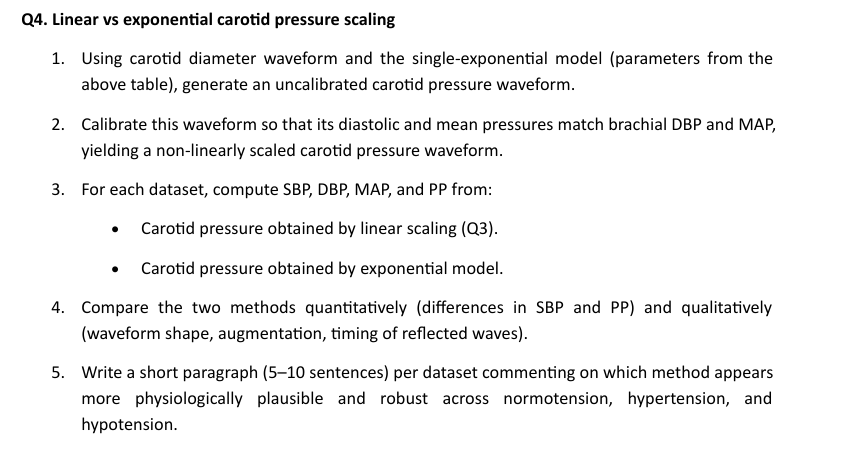

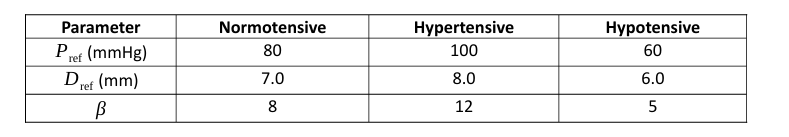

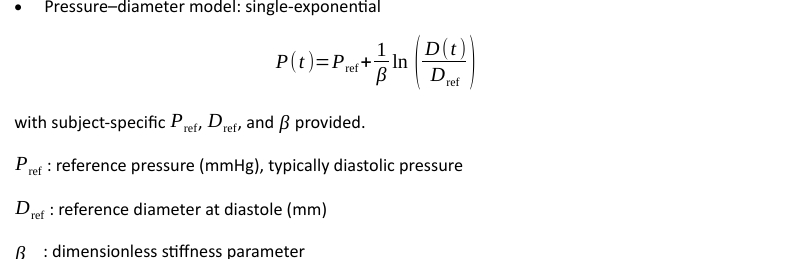
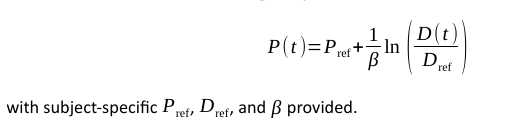

In [45]:
type=["Normotensive", "Hypertensive", "Hypotensive"]
Pref=[80,100,60]
Dref=[7.0,8.0,6.0]
Beta=[8,12,5]